# Food Delivery Business Performance — Visualization Portfolio

### Objective

This notebook performs a complete visualization analysis of the Food Delivery Business Performance Dataset using **Pandas, Matplotlib, and Seaborn**.

The analysis investigates:

- Changes in orders and revenue over time
- Differences in performance between cities
- Differences between cuisines
- Relationship between marketing spend and revenue
- Relationship between delivery time and customer ratings
- Distribution of orders
- Revenue variation across cities
- Effect of weather on delivery time
- Performance of different order channels
- Correlations between important numerical variables

The notebook contains different types of visualizations including:

1. Line plots
2. Bar charts
3. Scatter plots
4. Histograms
5. Box plots
6. Violin plots
7. Count plots
8. Correlation heatmap

Each visualization is followed by a brief interpretation of the insight revealed by the chart.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [4]:
df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [6]:
#Basic Dataset information
print("Dataset Information:")
print("=" * 50)

df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Custo

In [8]:
#Descriptive Information
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [10]:
#Check Missing values
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64

In [14]:
df.dtypes

Order_Batch_ID              object
Date                        object
Month                       object
Day                         object
City                        object
Cuisine                     object
Order_Channel               object
Weather                     object
Orders                       int64
Average_Order_Value        float64
Revenue                    float64
Marketing_Spend            float64
Discounts                  float64
Avg_Delivery_Minutes       float64
Customer_Rating            float64
Repeat_Customer_Percent    float64
dtype: object

In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Order_Batch_ID                     object
Date                       datetime64[ns]
Month                              object
Day                                object
City                               object
Cuisine                            object
Order_Channel                      object
Weather                            object
Orders                              int64
Average_Order_Value               float64
Revenue                           float64
Marketing_Spend                   float64
Discounts                         float64
Avg_Delivery_Minutes              float64
Customer_Rating                   float64
Repeat_Customer_Percent           float64
dtype: object

In [20]:
# Define correct month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Group data by month
monthly_data = (
    df.assign(
        Month=pd.Categorical(
            df["Month"],
            categories=month_order,
            ordered=True
        )
    )
    .groupby("Month", observed=True)[["Orders", "Revenue"]]
    .sum()
)

monthly_data

,Orders,Revenue
Month,,
January,3318,1307391.72
February,2853,1129272.69
March,5073,2143752.84
April,5343,2177469.56
May,3433,1395617.16
June,5816,2366928.56
July,4107,1737726.54
August,4951,1877308.87
September,3782,1515392.97


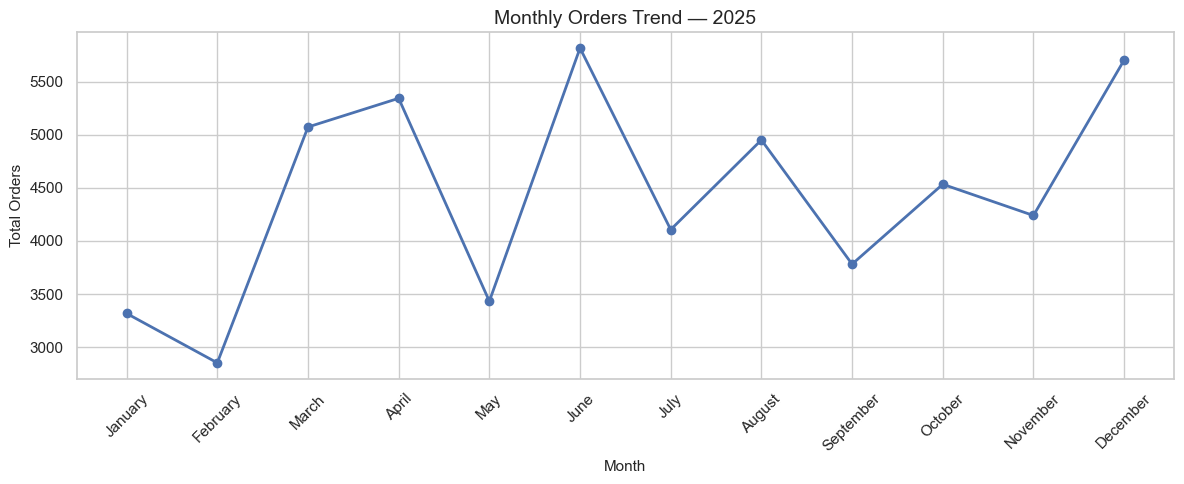

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data.index,
    monthly_data["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Orders Trend — 2025")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The line plot shows how order volume changes throughout the year. There are noticeable month-to-month fluctuations, indicating that demand is not constant throughout the year. The months with higher order volumes represent stronger demand periods and may require additional operational capacity.

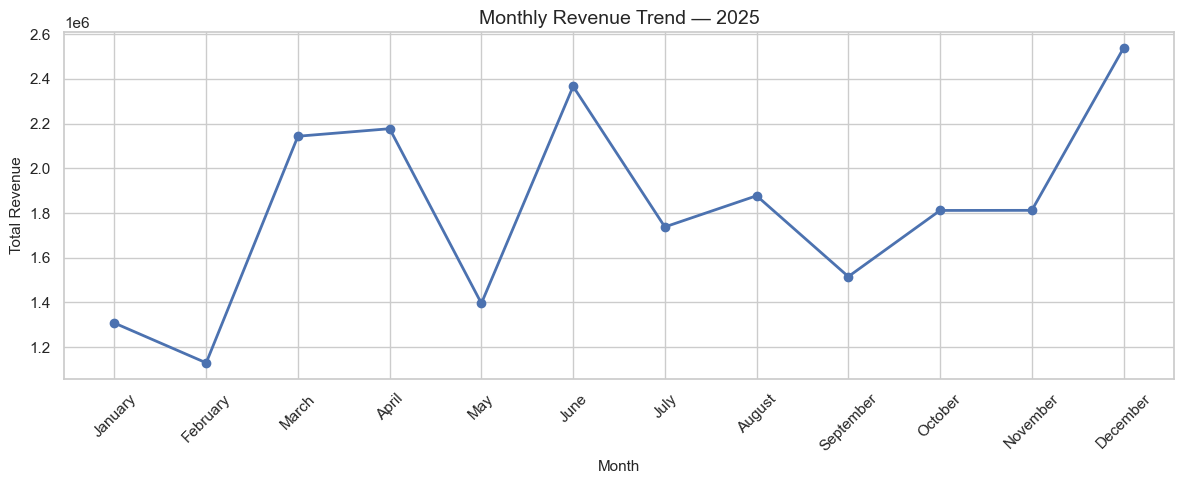

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data.index,
    monthly_data["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend — 2025")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Revenue varies across the months and generally follows changes in order volume. Months with higher demand tend to generate greater revenue. This indicates that seasonal demand is an important factor in the business's financial performance.

In [28]:
best_month = monthly_data["Revenue"].idxmax()
worst_month = monthly_data["Revenue"].idxmin()

print("Highest Revenue Month:", best_month)
print("Lowest Revenue Month:", worst_month)

print("\nHighest Revenue:", monthly_data["Revenue"].max())
print("Lowest Revenue:", monthly_data["Revenue"].min())

Highest Revenue Month: December
Lowest Revenue Month: February

Highest Revenue: 2538434.94
Lowest Revenue: 1129272.69


In [34]:
#Average Revenue by City
city_data = (
    df.groupby("City")[["Orders", "Revenue", "Customer_Rating", "Avg_Delivery_Minutes"]].mean().sort_values("Revenue", ascending=False))

city_data

,Orders,Revenue,Customer_Rating,Avg_Delivery_Minutes
City,,,,
Bengaluru,177.245283,72678.465094,4.433962,33.011321
Delhi,175.245283,71852.526038,4.406415,33.816981
Mumbai,161.780488,66595.214390,4.417317,33.663415
Hyderabad,148.750000,58841.311250,4.471667,32.172917
Pune,138.380952,57292.229286,4.469286,32.207143
Chandigarh,125.050000,50860.405500,4.492000,31.962500
Jaipur,117.404762,50696.350000,4.484048,31.580952
Kochi,120.804878,49461.841707,4.463902,31.802439


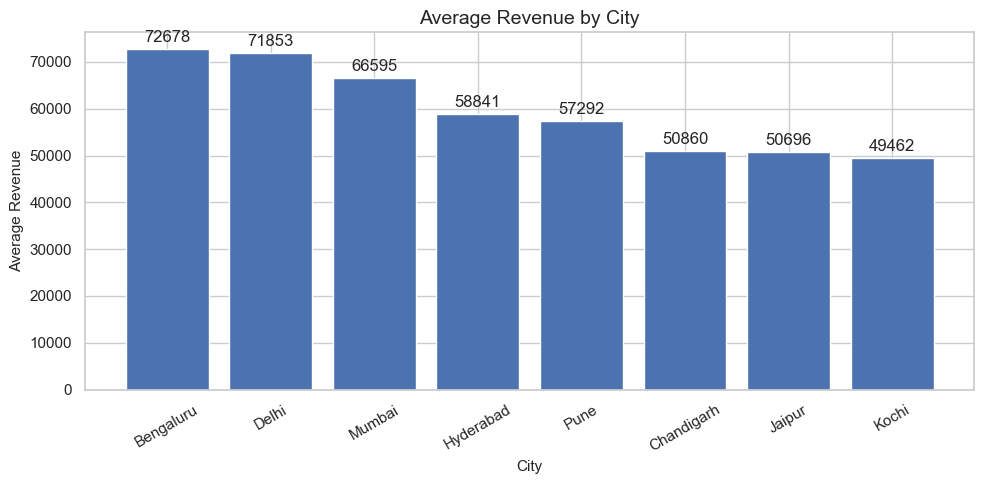

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(city_data.index, city_data["Revenue"])

ax.set_title("Average Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Average Revenue")

plt.xticks(rotation=30)

ax.bar_label(bars, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### Interpretation

Revenue performance differs between cities. Some cities generate substantially higher average revenue than others. This suggests that geographic market conditions, demand levels, customer spending, and order composition can influence business performance.

In [39]:
best_city = city_data["Revenue"].idxmax()
worst_city = city_data["Revenue"].idxmin()

print("Highest Average Revenue City:", best_city)
print("Lowest Average Revenue City:", worst_city)

Highest Average Revenue City: Bengaluru
Lowest Average Revenue City: Kochi


In [41]:
#Average Revenue by Cuisine
cuisine_data = (df.groupby("Cuisine")[["Orders", "Revenue", "Customer_Rating"]].mean().sort_values("Revenue", ascending=False))

display(cuisine_data)

,Orders,Revenue,Customer_Rating
Cuisine,,,
Healthy,147.411765,73362.597941,4.445441
Biryani,145.375000,67145.634286,4.438571
North Indian,148.032787,64186.963770,4.497213
Chinese,145.507937,57053.402222,4.442063
South Indian,151.648148,52567.543148,4.453148
Fast Food,148.310345,46820.218621,4.440172


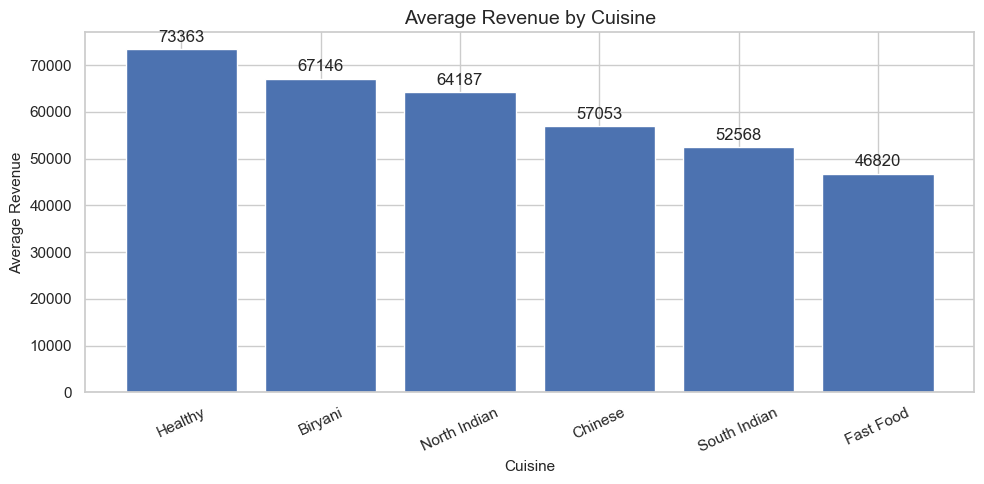

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    cuisine_data.index,
    cuisine_data["Revenue"]
)

ax.set_title("Average Revenue by Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Average Revenue")

plt.xticks(rotation=25)

ax.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

### Interpretation

Different cuisines generate different levels of average revenue. The highest-performing cuisine may have a combination of higher demand and/or higher average order value. This information can help the business identify cuisines that deserve greater promotional attention.

In [46]:
best_cuisine = cuisine_data["Revenue"].idxmax()
worst_cuisine = cuisine_data["Revenue"].idxmin()

print("Highest Average Revenue Cuisine:", best_cuisine)
print("Lowest Average Revenue Cuisine:", worst_cuisine)

Highest Average Revenue Cuisine: Healthy
Lowest Average Revenue Cuisine: Fast Food


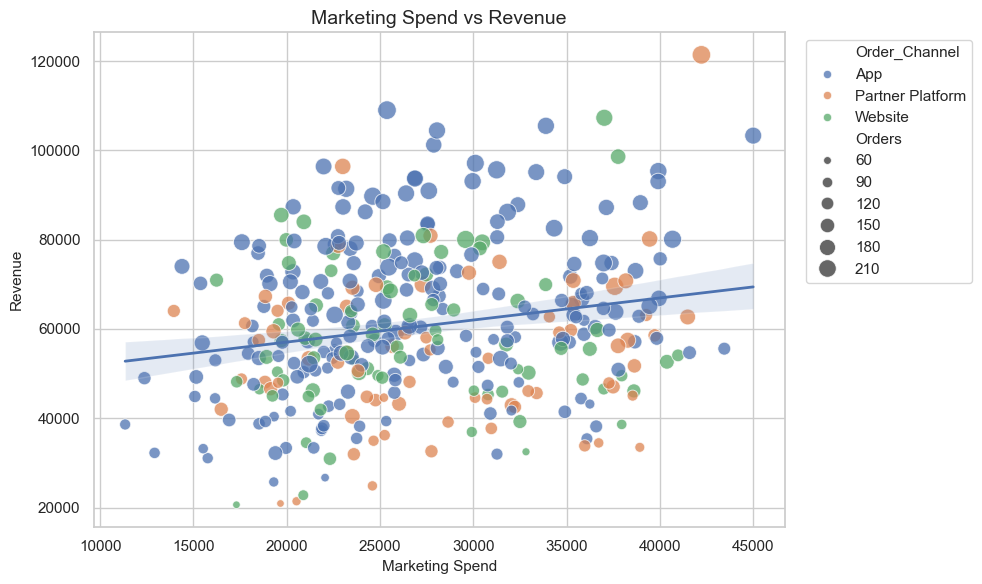

In [48]:
#Marketing Spend vs Revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    hue="Order_Channel",
    size="Orders",
    sizes=(30, 180),
    alpha=0.75
)

sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter=False,
    line_kws={"linewidth": 2}
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot helps investigate whether higher marketing expenditure is associated with higher revenue. The points show considerable variation, indicating that marketing spend alone does not completely explain revenue. Other factors such as orders, average order value, city, cuisine, and seasonality are also likely to influence revenue.

In [51]:
#Marketing Correlation
marketing_correlation = df["Marketing_Spend"].corr(
    df["Revenue"]
)

print(
    "Correlation between Marketing Spend and Revenue:",
    round(marketing_correlation, 2)
)

Correlation between Marketing Spend and Revenue: 0.2


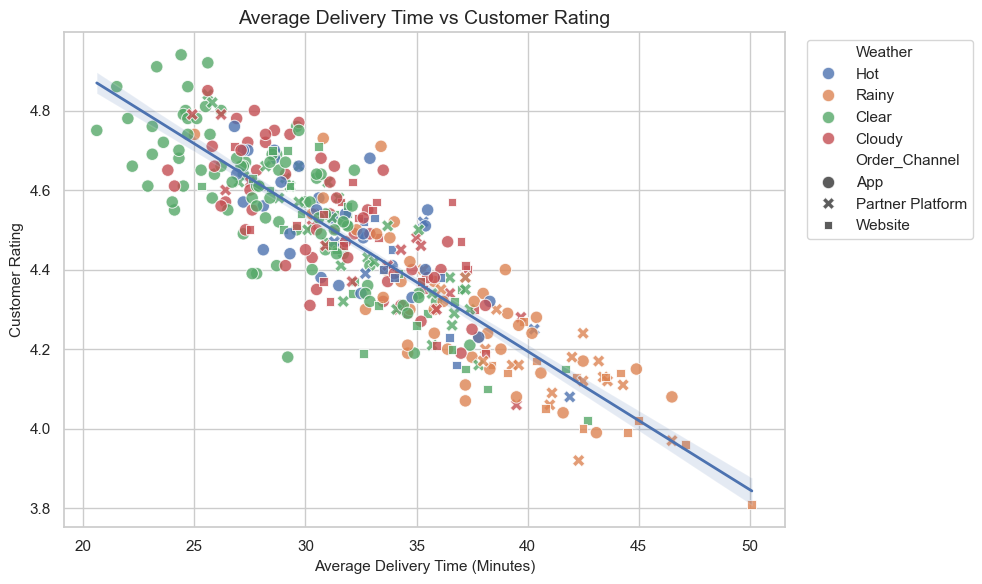

In [53]:
#Delivery Time vs Customer Rating
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    hue="Weather",
    style="Order_Channel",
    s=80,
    alpha=0.8
)

sns.regplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    scatter=False,
    line_kws={"linewidth": 2}
)

plt.title("Average Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot indicates that customer ratings generally decrease as delivery time increases. This suggests that faster delivery is an important factor in maintaining customer satisfaction. Longer delivery times may negatively affect the customer experience.

In [56]:
#Delivery time and Rating Correlation
delivery_rating_correlation = df[
    "Avg_Delivery_Minutes"
].corr(
    df["Customer_Rating"]
)

print(
    "Correlation between Delivery Time and Customer Rating:",
    round(delivery_rating_correlation, 2)
)

Correlation between Delivery Time and Customer Rating: -0.88


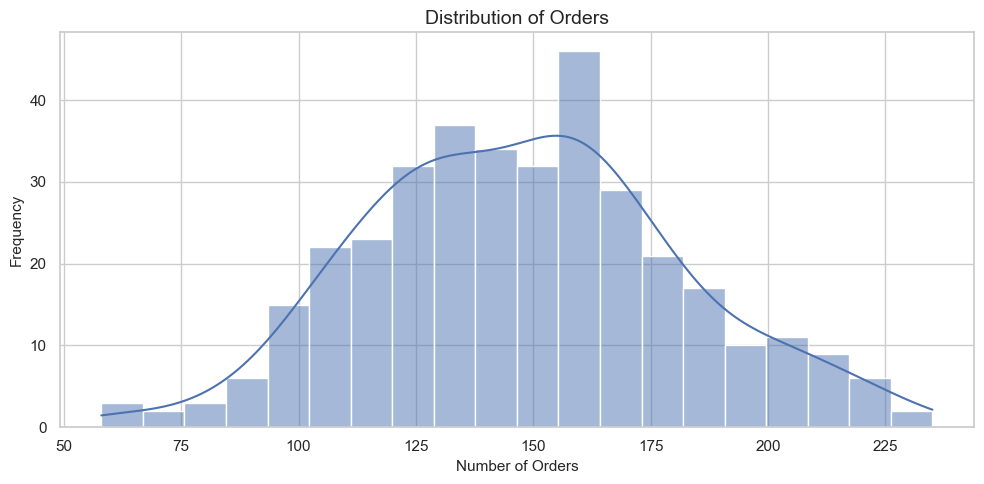

In [58]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Orders"],
    bins=20,
    kde=True
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The histogram shows the distribution of order volumes across observations. Most observations are concentrated within a central range, while a smaller number of observations have particularly high order volumes. These high-volume observations may represent periods of unusually strong demand.

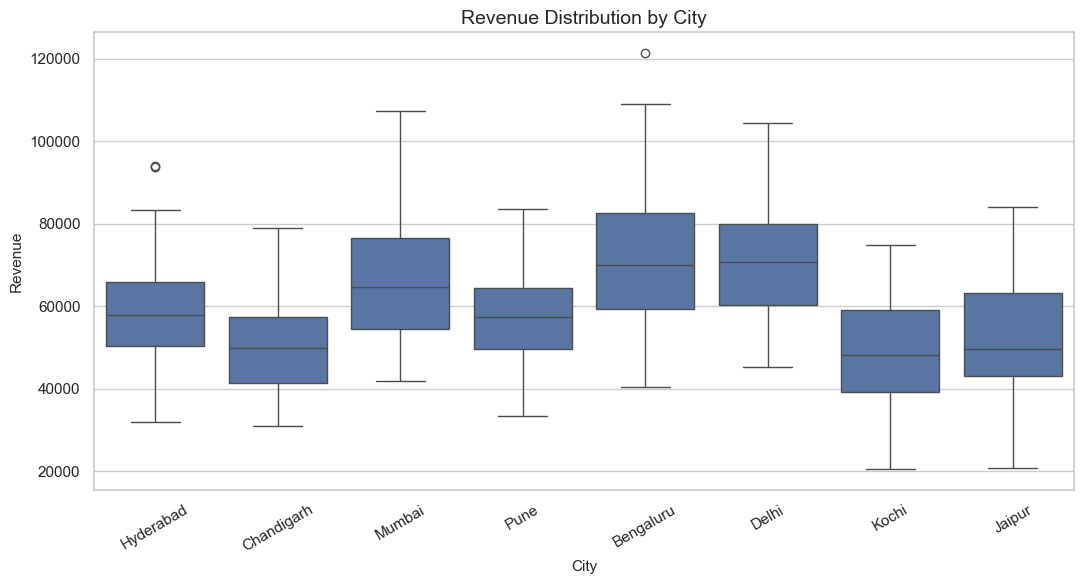

In [61]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)

plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

The box plot shows the median, spread, and potential outliers of revenue for each city. Revenue can vary considerably within the same city, showing that city-level averages alone do not capture the complete distribution of business performance.

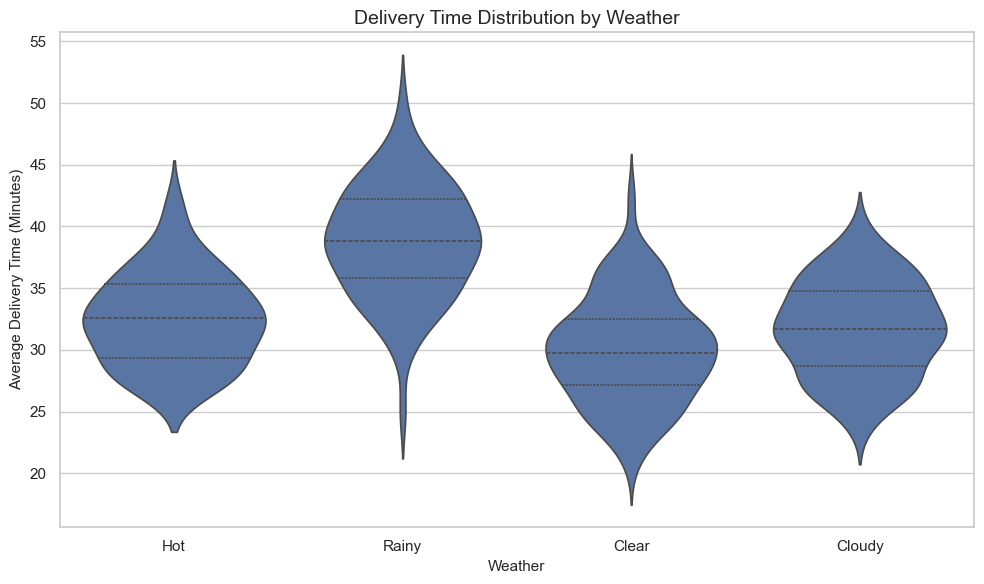

In [64]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Weather",
    y="Avg_Delivery_Minutes",
    inner="quartile"
)

plt.title("Delivery Time Distribution by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (Minutes)")

plt.tight_layout()
plt.show()

### Interpretation

Weather conditions affect delivery time. Adverse weather conditions, particularly rainy conditions, tend to be associated with longer delivery times. This suggests that weather-related operational challenges can affect delivery efficiency.

In [67]:
weather_data = (
    df.groupby("Weather")
      [["Orders",
        "Revenue",
        "Avg_Delivery_Minutes",
        "Customer_Rating"]]
      .mean()
      .sort_values(
          "Avg_Delivery_Minutes",
          ascending=False
      )
)

display(weather_data)

,Orders,Revenue,Avg_Delivery_Minutes,Customer_Rating
Weather,,,,
Rainy,148.106667,60160.236533,38.748000,4.232000
Hot,152.288889,59388.019556,32.466667,4.472444
Cloudy,144.978723,59935.805532,31.719149,4.498830
Clear,147.698630,61605.184795,29.994521,4.530685


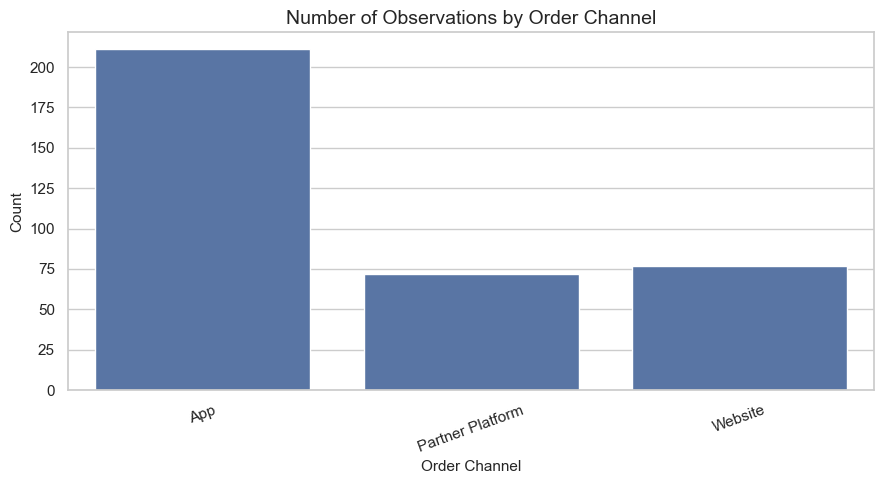

In [69]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Order_Channel"
)

plt.title("Number of Observations by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

The count plot shows the distribution of observations across order channels. The App represents the largest share of observations, followed by the other available channels. This indicates that the mobile application is an important channel in the dataset.

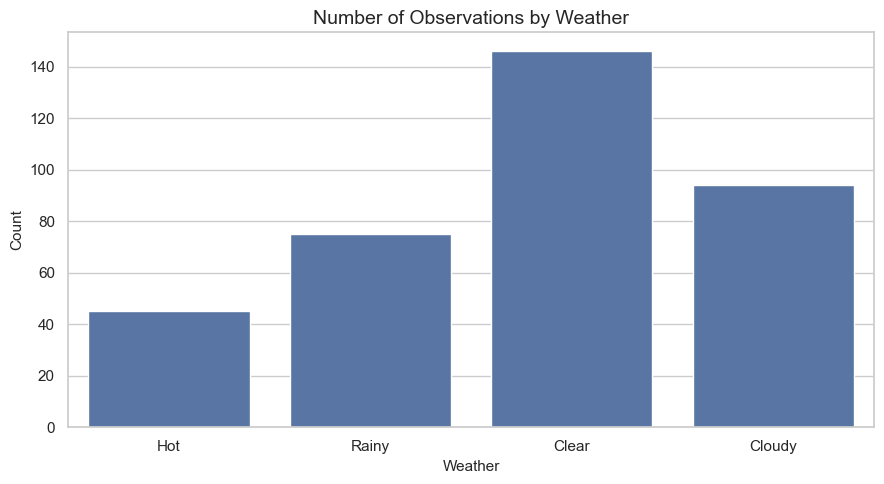

In [74]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Number of Observations by Weather")
plt.xlabel("Weather")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation

Clear weather is represented more frequently than adverse weather conditions. This provides useful context when interpreting the weather-related performance charts because the number of observations is not equal across all weather categories.

In [77]:
channel_data = (
    df.groupby("Order_Channel")
      [["Orders", "Revenue", "Customer_Rating"]]
      .mean()
      .sort_values("Revenue", ascending=False)
)

display(channel_data)

,Orders,Revenue,Customer_Rating
Order_Channel,,,
App,153.246445,63675.734313,4.509005
Website,140.298701,58066.339221,4.366494
Partner Platform,139.097222,54251.573056,4.380694


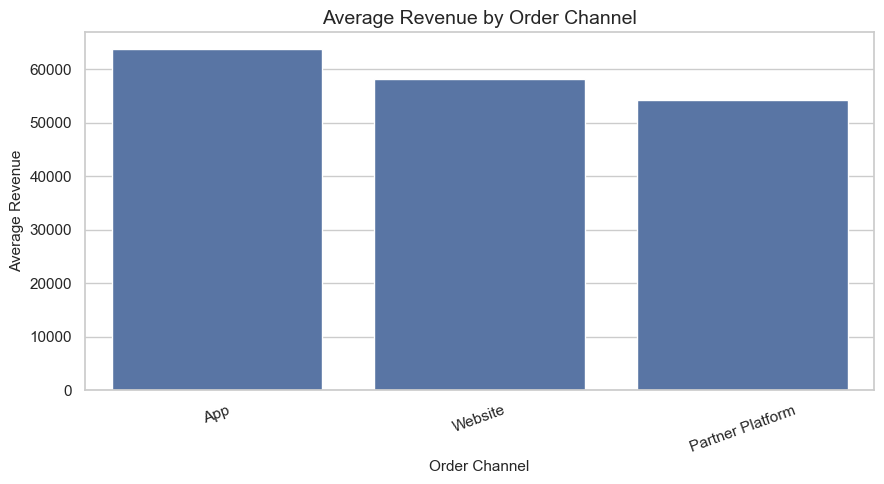

In [79]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_data.reset_index(),
    x="Order_Channel",
    y="Revenue"
)

plt.title("Average Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Revenue")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

Average revenue differs across order channels. The channel with the highest average revenue may be particularly valuable from a business perspective. However, channel performance should also be considered alongside customer ratings, order volume, and operational costs.

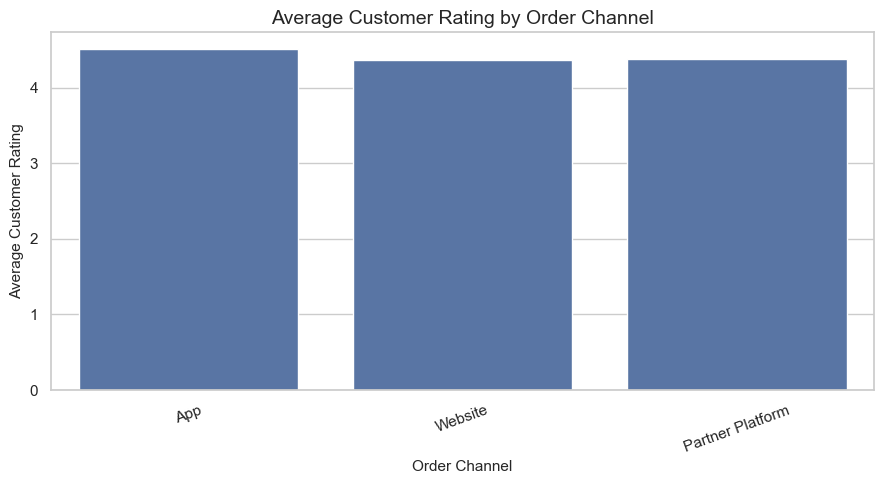

In [84]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_data.reset_index(),
    x="Order_Channel",
    y="Customer_Rating"
)

plt.title("Average Customer Rating by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Customer Rating")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

Customer ratings differ across order channels. A channel with a higher rating may provide a better customer experience, while a lower rating could indicate issues related to ordering, communication, delivery, or service quality.

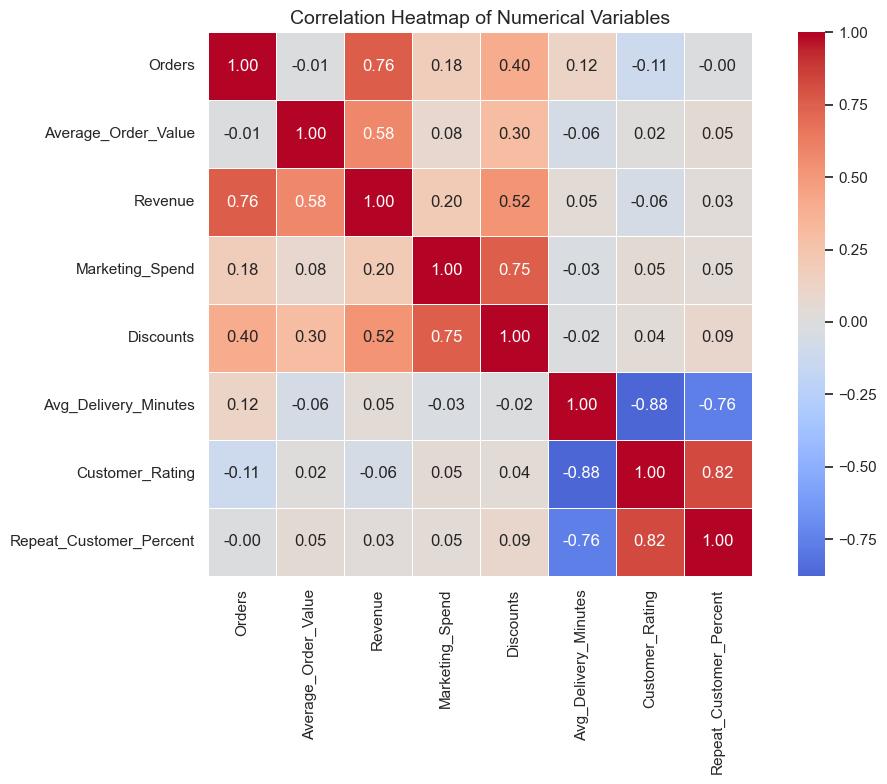

In [87]:
numeric_columns = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap provides an overall view of relationships between numerical variables.

Revenue is strongly related to orders and average order value because these variables directly contribute to revenue generation.

Delivery time has a negative relationship with customer rating, supporting the earlier scatter plot finding that longer deliveries tend to be associated with lower customer satisfaction.

Marketing spend has a weaker relationship with revenue, indicating that marketing expenditure alone is not sufficient to explain revenue performance.

In [90]:
#Summary
print("KEY BUSINESS METRICS")
print("=" * 50)

print("Total Orders:", df["Orders"].sum())
print("Total Revenue:", df["Revenue"].sum())

print(
    "Average Order Value:",
    round(df["Average_Order_Value"].mean(), 2)
)

print(
    "Average Delivery Time:",
    round(df["Avg_Delivery_Minutes"].mean(), 2),
    "minutes"
)

print(
    "Average Customer Rating:",
    round(df["Customer_Rating"].mean(), 2)
)

print(
    "Average Marketing Spend:",
    round(df["Marketing_Spend"].mean(), 2)
)

KEY BUSINESS METRICS
Total Orders: 53153
Total Revenue: 21812801.32
Average Order Value: 409.15
Average Delivery Time: 32.58 minutes
Average Customer Rating: 4.45
Average Marketing Spend: 27161.43


In [92]:
#Important findings
best_month = monthly_data["Revenue"].idxmax()
worst_month = monthly_data["Revenue"].idxmin()

best_city = city_data["Revenue"].idxmax()
worst_city = city_data["Revenue"].idxmin()

best_cuisine = cuisine_data["Revenue"].idxmax()
worst_cuisine = cuisine_data["Revenue"].idxmin()

best_channel = channel_data["Revenue"].idxmax()

print("Highest Revenue Month:", best_month)
print("Lowest Revenue Month:", worst_month)

print("Highest Average Revenue City:", best_city)
print("Lowest Average Revenue City:", worst_city)

print("Highest Average Revenue Cuisine:", best_cuisine)
print("Lowest Average Revenue Cuisine:", worst_cuisine)

print("Highest Average Revenue Order Channel:", best_channel)

print(
    "Marketing Spend vs Revenue Correlation:",
    round(marketing_correlation, 2)
)

print(
    "Delivery Time vs Customer Rating Correlation:",
    round(delivery_rating_correlation, 2)
)

Highest Revenue Month: December
Lowest Revenue Month: February
Highest Average Revenue City: Bengaluru
Lowest Average Revenue City: Kochi
Highest Average Revenue Cuisine: Healthy
Lowest Average Revenue Cuisine: Fast Food
Highest Average Revenue Order Channel: App
Marketing Spend vs Revenue Correlation: 0.2
Delivery Time vs Customer Rating Correlation: -0.88


# Final Summary and Key Findings

The visualization analysis provides several important insights into the food delivery business.

### 1. Orders and Revenue

Monthly orders and revenue fluctuate throughout the year. Higher order volumes generally correspond to higher revenue, indicating that demand and seasonality have an important effect on business performance.

### 2. City Performance

Revenue differs significantly between cities. Some cities consistently generate higher average revenue, suggesting that geographical market characteristics, customer demand, and order value influence performance.

### 3. Cuisine Performance

Different cuisines show different revenue levels. Identifying high-performing cuisines can help the business optimize promotions, menu offerings, and marketing strategies.

### 4. Marketing Spend

Marketing spend has a positive but relatively limited relationship with revenue. This indicates that simply increasing marketing expenditure may not guarantee proportional revenue growth.

### 5. Delivery Time and Customer Satisfaction

Delivery time has a negative relationship with customer rating. Longer delivery times tend to be associated with lower customer satisfaction. Improving delivery speed and reliability should therefore be an important operational priority.

### 6. Weather Impact

Weather conditions influence delivery performance. Rainy or adverse weather tends to increase delivery times, which can subsequently affect customer satisfaction.

### 7. Order Channels

The App represents a major order channel in the dataset. Differences in revenue and customer ratings across channels suggest that the business should monitor channel-level performance carefully.

### 8. Overall Business Insight

The analysis suggests that food delivery performance depends on several interconnected factors rather than a single variable. **Order volume, average order value, city, cuisine, marketing activity, delivery efficiency, weather, and order channel all contribute to overall business performance.**

The most important operational finding is the relationship between **delivery time and customer satisfaction**. Improving delivery reliability, especially during adverse weather, could help improve customer experience and potentially support customer retention.

> **Note:** These visualizations identify patterns and associations in the dataset. They do not prove that one variable directly causes another.